### Import Libraries

In [115]:
from sqlalchemy import create_engine
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings 
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
%matplotlib inline
warnings.filterwarnings("ignore")

### Connect To The Server

In [117]:
conn_str = (
    "mssql+pyodbc://@DESKTOP-TUS2GTK/Banking_Risk"
    "?driver=ODBC Driver 17 for SQL Server"
    "&trusted_connection=yes")

engine = create_engine(conn_str)
df = pd.read_sql("SELECT * FROM Banking_Data", engine)

In [119]:
df

,Client ID,Name,Age,Location ID,Joined Bank,Banking Contact,Nationality,Occupation,Fee Structure,Loyalty Classification,...,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,GenderId,IAId
0,IND81288,Raymond Mills,24,34324,06-05-2019,Anthony Torres,American,Safety Technician IV,High,Jade,...,1485828.64,603617.88,607332.46,12249.96,1134475.30,1,2,1,1,1
1,IND65833,Julia Spencer,23,42205,10-12-2001,Jonathan Hawkins,African,Software Consultant,High,Jade,...,641482.79,229521.37,344635.16,61162.31,2000526.10,1,3,2,1,2
2,IND47499,Stephen Murray,27,7314,25-01-2010,Anthony Berry,European,Help Desk Operator,High,Gold,...,1033401.59,652674.69,203054.35,79071.78,548137.58,1,3,3,2,3
3,IND72498,Virginia Garza,40,34594,28-03-2019,Steve Diaz,American,Geologist II,Mid,Silver,...,1048157.49,1048157.49,234685.02,57513.65,1148402.29,0,4,4,1,4
4,IND60181,Melissa Sanders,46,41269,20-07-2012,Shawn Long,American,Assistant Professor,Mid,Platinum,...,487782.53,446644.25,128351.45,30012.14,1674412.12,0,3,1,2,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,IND66827,Earl Hall,82,8760,09-10-2014,Joshua Bennett,American,Accounting Assistant III,High,Gold,...,1089957.03,532867.88,657849.62,12947.31,1238859.91,1,3,3,2,4
2996,IND40556,Billy Williamson,44,32837,05-02-2009,Dennis Ruiz,European,Paralegal,Mid,Gold,...,136891.32,56581.74,93195.61,23205.69,277171.07,1,2,3,2,5
2997,IND72414,Victor Black,70,36088,29-12-2009,Joshua Ryan,American,Statistician IV,Low,Jade,...,214860.89,158726.06,35539.15,30291.81,502947.22,2,2,3,2,6
2998,IND46652,Andrew Ford,56,24871,13-02-2006,Nicholas Cunningham,European,Human Resources Assistant III,Mid,Jade,...,742630.22,404638.26,56411.33,6413.14,1538368.60,3,1,3,2,7


### Data Exploration

In [121]:
df.duplicated().sum()

0

In [123]:
df.isna().sum()

Client ID                   0
Name                        0
Age                         0
Location ID                 0
Joined Bank                 0
Banking Contact             0
Nationality                 0
Occupation                  0
Fee Structure               0
Loyalty Classification      0
Estimated Income            0
Superannuation Savings      0
Amount of Credit Cards      0
Credit Card Balance         0
Bank Loans                  0
Bank Deposits               0
Checking Accounts           0
Saving Accounts             0
Foreign Currency Account    0
Business Lending            0
Properties Owned            0
Risk Weighting              0
BRId                        0
GenderId                    0
IAId                        0
dtype: int64

### Data Cleaning

In [125]:
cols_to_numeric = [
    'Estimated Income', 'Superannuation Savings', 'Credit Card Balance',
    'Bank Loans', 'Bank Deposits', 'Checking Accounts', 'Saving Accounts',
    'Foreign Currency Account', 'Business Lending'
]

In [127]:
for col in cols_to_numeric :
    df[col] = df[col].replace("," ,"", regex = True).astype(float)

In [129]:
df2 = df[df['Age'].between(18,100)]

In [131]:
data = df2[df2['Credit Card Balance'] >= 0 ]

* Correlation To Show Effects Feartures

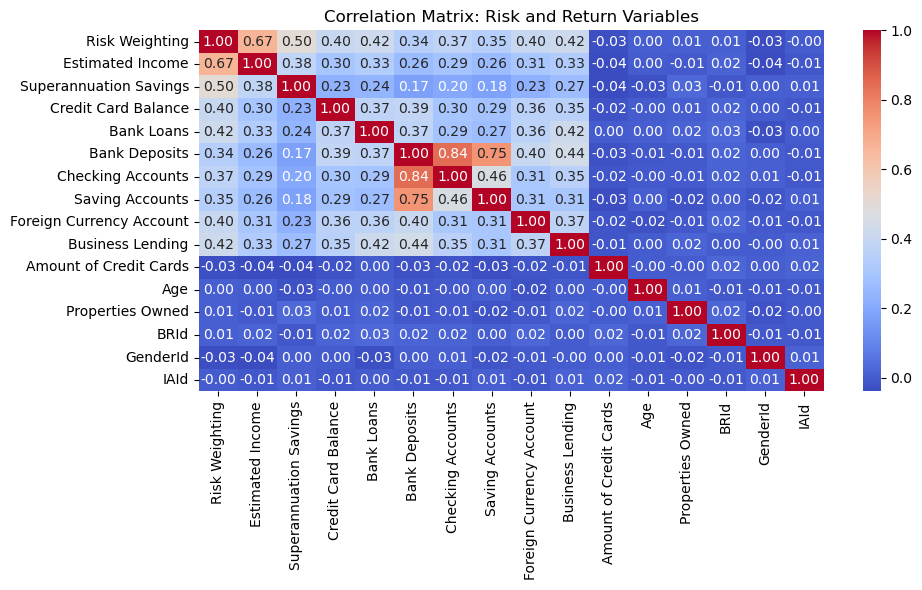

In [133]:
numerical_cols = ['Risk Weighting', 'Estimated Income','Superannuation Savings',
                  'Credit Card Balance', 'Bank Loans', 'Bank Deposits' ,'Checking Accounts', 'Saving Accounts',
                   'Foreign Currency Account' , 'Business Lending' ,'Amount of Credit Cards', 'Age', 'Properties Owned' , 'BRId' , 'GenderId' , 'IAId']

plt.figure(figsize=(10, 6))
corr_matrix = data[numerical_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix: Risk and Return Variables")
plt.tight_layout()
plt.show()

* To show Effect Of Categorical Columns In The Target

In [135]:
encoder = LabelEncoder()
categorical_columns = ['Nationality', 'Occupation', 'Fee Structure', 'Loyalty Classification']

for col in categorical_columns:
    data[col + '_encoded'] = encoder.fit_transform(data[col])

correlation_with_target = data[['Nationality_encoded', 'Occupation_encoded', 'Fee Structure_encoded', 'Loyalty Classification_encoded',
                              'Risk Weighting']].corr()

print(correlation_with_target['Risk Weighting'])

Nationality_encoded               0.026830
Occupation_encoded                0.019455
Fee Structure_encoded            -0.007876
Loyalty Classification_encoded   -0.004138
Risk Weighting                    1.000000
Name: Risk Weighting, dtype: float64


* Drop Unneeded Features

In [138]:
columns_to_drop = ['Name', 'Banking Contact', 'Location ID', 'Joined Bank', 
                   'IAId', 'BRId', 'GenderId', 'Properties Owned', 'Age', 'Amount of Credit Cards', 
                   'Nationality', 'Occupation', 'Fee Structure', 'Loyalty Classification' , 'Nationality_encoded' , 'Occupation_encoded' 
                    'Fee Structure_encoded' , 'Loyalty Classification_encoded' ,'Occupation_encoded' , 'Fee Structure_encoded']

existing_columns_to_drop = [col for col in columns_to_drop if col in data.columns]
data.drop(columns=existing_columns_to_drop, axis=1, inplace=True)

In [140]:
data['Monthly Income'] = ((data['Estimated Income'] / 12).astype(int))

In [142]:
data.to_csv('E:\Projects\Banking Risks\Dataset\Cleand_Dataa.csv')

### analyzing risk vs. return patterns 

In [43]:
data[['Estimated Income' , 'Risk Weighting']].describe().T

,count,mean,std,min,25%,50%,75%,max
Estimated Income,2961.0,171090.256285,112006.912007,15919.48,82651.24,142319.85,241146.8,522330.26
Risk Weighting,2961.0,2.246876,1.131032,1.00,1.00,2.00,3.0,5.00


In [144]:
Correlation = data['Risk Weighting'].corr(data['Estimated Income'])
Correlation

0.6658398002445315

* Positive Relationship -> Higher risk correlates with higher income

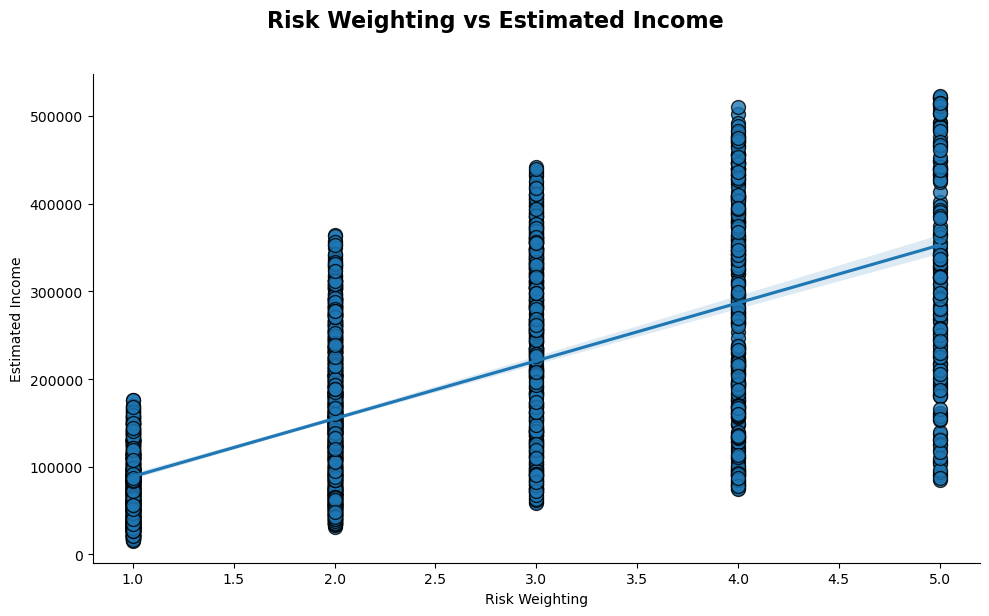

In [146]:
g = sns.lmplot(data=data,x='Risk Weighting',y='Estimated Income',height=6, aspect=10/6,        
               scatter_kws={'s': 100,'edgecolor': 'black','alpha': 0.8},
               legend_out=False)

g.fig.suptitle("Risk Weighting vs Estimated Income", fontsize=16, weight='bold', y=1.02)
g.set_axis_labels("Risk Weighting", "Estimated Income")
g.ax.grid(False)
plt.tight_layout()

* Most For Features Effect The Risk

In [149]:
features = ['Estimated Income', 'Bank Loans', 'Bank Deposits', 'Credit Card Balance']
df_clean = data[features + ['Risk Weighting']].dropna() 

scaled = StandardScaler().fit_transform(df_clean[features])

kmeans = KMeans(n_clusters=4, random_state=42)
df_clean['RiskCluster'] = kmeans.fit_predict(scaled)

data.loc[df_clean.index, 'RiskCluster'] = df_clean['RiskCluster']

cluster_risk_means = data.groupby('RiskCluster')['Risk Weighting'].mean().sort_values()
risk_order = ['Low Risk', 'Medium Risk', 'High Risk', 'Very High Risk'] 
risk_labels = {cluster: risk_order[i] for i, cluster in enumerate(cluster_risk_means.index)}

data['RiskLevel'] = data['RiskCluster'].map(risk_labels)

Cluster 0: High income, high loans → Possibly High Risk due to high liabilities

Cluster 1: Low income, low loans → Possibly Low Risk

Cluster 2: Medium income, high deposits → Possibly Low Risk

Cluster 3: Low income, high loans and high credit card balance → Possibly Very High Risk

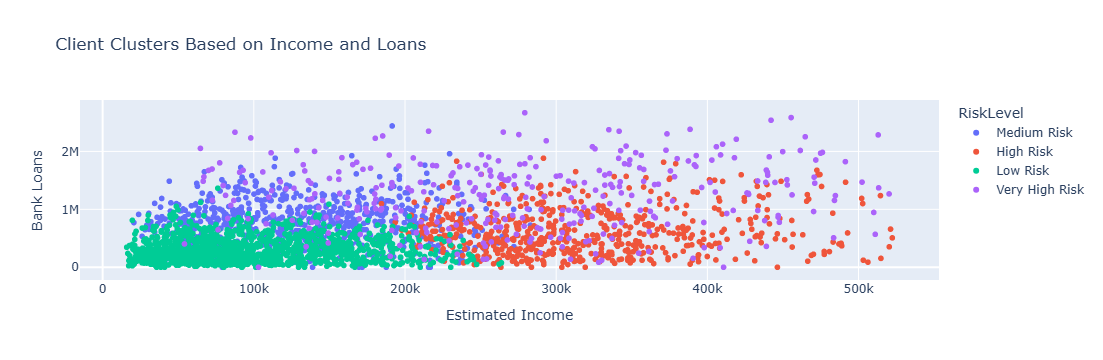

In [155]:
fig = px.scatter(data,x='Estimated Income',y='Bank Loans',color='RiskLevel',title='Client Clusters Based on Income and Loans',
    hover_data=['Bank Deposits', 'Credit Card Balance', 'Risk Weighting'])
fig.show()

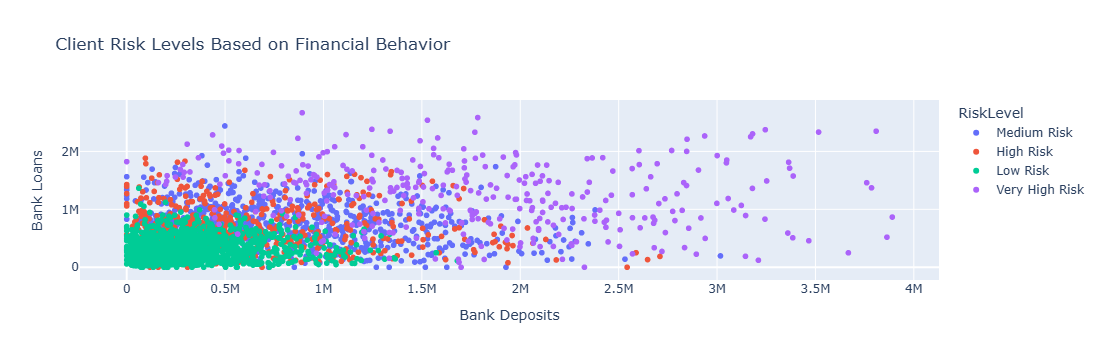

In [153]:
fig = px.scatter(data, x='Bank Deposits', y='Bank Loans', color='RiskLevel', title='Client Risk Levels Based on Financial Behavior',
                 hover_data=['Estimated Income', 'Credit Card Balance', 'Risk Weighting'])

fig.show()

### Some Statistics Analysis

* If p-value < 0.05 → there is a statistically significant difference in Feature across risk levels.

* If p-value ≥ 0.05 → no significant difference.

In [158]:
features = ['Estimated Income', 'Bank Loans', 'Bank Deposits', 'Credit Card Balance']

for feature in features:
    grouped_data = [group[feature].values for name, group in data.groupby("RiskLevel")]
    f_stat, p_value = f_oneway(*grouped_data)
    print(f"{feature} — F: {f_stat:.2f}, p: {p_value:.4f}")

Estimated Income — F: 1827.60, p: 0.0000
Bank Loans — F: 784.95, p: 0.0000
Bank Deposits — F: 915.60, p: 0.0000
Credit Card Balance — F: 895.90, p: 0.0000


### Data For Customers Have High Risk And Very High Risk

In [160]:
filtered_data = data[data['RiskLevel'].isin(['Very High Risk', 'High Risk'])]
filtered_data

,Client ID,Estimated Income,Superannuation Savings,Credit Card Balance,Bank Loans,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Risk Weighting,Monthly Income,RiskCluster,RiskLevel
1,IND65833,289834.31,17398.92,2256.88,1270615.43,641482.79,229521.37,344635.16,61162.31,2000526.10,3,24152,2.0,High Risk
3,IND72498,356808.11,5473.15,4205.00,121195.06,1048157.49,1048157.49,234685.02,57513.65,1148402.29,4,29734,2.0,High Risk
14,IND86325,260795.34,11584.68,2866.34,310876.62,116399.86,69072.45,67077.02,48101.13,1136169.30,2,21732,2.0,High Risk
16,IND28503,257120.22,16263.99,8614.06,436988.44,2446251.57,1273391.23,253337.83,80698.26,1128082.14,3,21426,0.0,Very High Risk
22,IND93121,308182.93,64332.66,4458.61,649331.84,103871.63,77431.58,133711.12,12045.07,176113.98,5,25681,2.0,High Risk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2986,IND99892,474482.25,70427.70,1070.78,1601301.31,1020310.16,637693.85,429217.02,850.82,2141715.89,4,39540,2.0,High Risk
2988,IND24501,353210.83,32236.84,2521.03,774648.50,324112.57,324112.57,87369.48,19955.59,177248.76,2,29434,2.0,High Risk
2990,IND19589,322668.50,8959.30,4241.51,895255.97,1184493.52,762894.13,134911.80,36303.53,913863.27,2,26889,2.0,High Risk
2994,IND24309,297850.41,53289.54,4327.91,990326.11,838261.60,630618.82,83057.11,13537.02,180596.00,5,24820,2.0,High Risk
